In [27]:
import math
import numpy as np

def dbinom(n_success: int, size: int, prob: float = 0.5) -> float:
    assert 0 <= prob <= 1, "p must be between 0 and 1"

    s = n_success
    f = size-n_success
    nk = math.factorial(size)/(math.factorial(s)*math.factorial(f))

    return nk*(prob**s)*((1-prob)**(f))


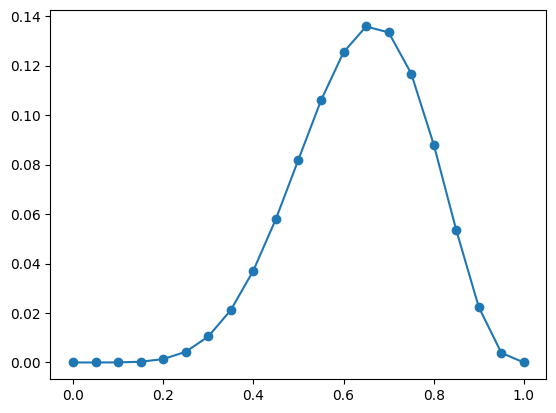

In [42]:
import matplotlib.pyplot as plt

#Grid Approximation
p_grid = np.arange(0, 1.05, step=0.05)

# define prior
prior = [1]*21

#compute likelihood at each value in grid
likelihood = [dbinom(6, 9, prob=x) for x in p_grid]

# compute product of likelihood and prior

unstd_posterior = list(map(lambda x, y: x*y, likelihood, prior))

# standardize the posterior, so it sums to 1
posterior = unstd_posterior / sum(unstd_posterior)

plt.plot(p_grid, posterior)
plt.scatter(p_grid, posterior)
plt.show()

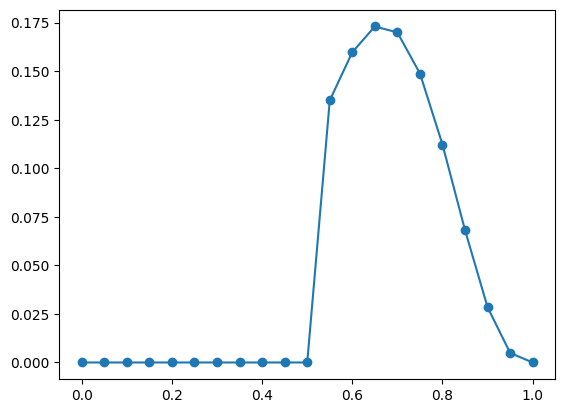

In [45]:
#Grid Approximation
p_grid = np.arange(0, 1.05, step=0.05)

# define prior
prior = [0 if x <= 0.5 else 1 for x in p_grid]

#compute likelihood at each value in grid
likelihood = [dbinom(6, 9, prob=x) for x in p_grid]

# compute product of likelihood and prior

unstd_posterior = list(map(lambda x, y: x*y, likelihood, prior))

# standardize the posterior, so it sums to 1
posterior = unstd_posterior / sum(unstd_posterior)

plt.plot(p_grid, posterior)
plt.scatter(p_grid, posterior)
plt.show()

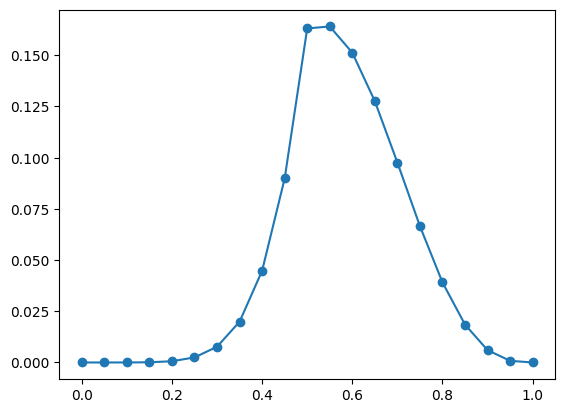

In [ ]:
#Grid Approximation
p_grid = np.arange(0, 1.05, step=0.05)


# define prior
prior = [np.exp(-5*np.abs(x-0.5)) for x in p_grid]

#compute likelihood at each value in grid
likelihood = [dbinom(6, 9, prob=x) for x in p_grid]

# compute product of likelihood and prior

unstd_posterior = list(map(lambda x, y: x*y, likelihood, prior))

# standardize the posterior, so it sums to 1
posterior = unstd_posterior / sum(unstd_posterior)

plt.plot(p_grid, posterior)
plt.scatter(p_grid, posterior)
plt.show()

## 2.6 Practice

**2E1) Which of the expressions below correspond to teh statment: *the probability of rain on Monday***
 1. Pr(rain)
 2. Pr(rain|Monday)
 3. Pr(Monday|rain)
 4. Pr(rain, Monday)/Pr(Monday)

 The correct answer is 2.

 *book answer*: 2 and 4

**2E2) Which of the following statements corresponds to teh expression: Pr(Monday|rain)?**
 1. The probability of rain on Monday.
 2. The probability of rain, given that it is Monday
 3. The Probability that it is Monday, given that it is raining
 4. THe probability that it is Monday and that it is raining.

 The correct answer is 3.

**2E3) Which of the expressions belwo correspond to the statement: *the probability that it is Monday, given that it is raining*?**
 1. Pr(Monday|rain)
 2. Pr(rain|Monday)
 3. Pr(rain|Monday) pr(Monday)
 4. Pr(rain|Monday) Pr(Monday)/Pr(rain)
 5. Pr(Monday|rain) Pr(rain)/Pr(Monday)

 Number one

 *book answer*: 1 and 4 - 4 is equivalent to Bayes Theorem

**2E4) The Bayesian statistician Bruno de Finetti (1906-1985) began his 1973 book on probability theory with the declaration: "PROBABILITY DOES NOT EXIST." The capitals appeared in the original , so I imagine de Finetti wanted us to shout this statement. What he meant is that probability is a device for describing uncertainty from the perspective of an observer with limited knowledge; it has no objective reality. Discuss the globe tossing example from the chapter, in light of this statement. What does it mean to say "the probability of water is 0.7"?**

The globe tossing example is a "small world" model built to help describe the relationship between the amount of water and the amount of land on Earth. To represent measuring the area of these two masses, a model is used to approximate the reality. In this sense, the model is trying to describe the percentage of the world that is covered in water. In reality the model is measuring the proportion of the time that an individuals finger lands on a space of water, which we hope approximates what we are actually trying to measure. 

*book answer*: The idea is that probability is only a subjective perception of the likelihood that something will happen. In the globe tossing example, the result will always be either “land” or “water” (i.e., 0 or 1). When we toss the globe, we don’t know what the result will be, but we know it will always be “land” or “water.” To express our uncertainty in the outcome, we use probability. Because we know that water is more likely than land, we may say that the probability of “water” is 0.7; however, we’ll never actually observe a result of 0.7 waters, or observe any probability. We will only ever observe the two results of “land” and “water.”

**2M1) Recall the globe tossing model from teh chapter. Compute and plot the grid approximate posterior distribution for each of teh following sets of observations. In each case, assume a uniform prior for p.**

 1. W, W, W
 2. W, W, W, L
 3. L, W, W, L, W, W, W

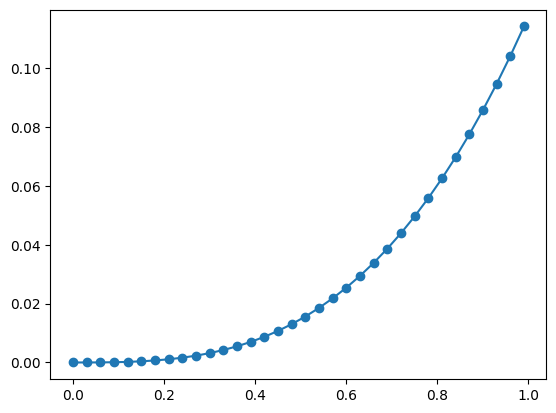

In [87]:
#1)

def grid_approx(n_success, n, n_points=30, prior="unif"):

    step = round(1/n_points, ndigits=2)
    p_grid = np.arange(0, 1+step, step=step)
    p_grid = [x for x in p_grid if x >= 0 and x <= 1]

    # define prior
    if prior == 'unif':
        prior = [1]*len(p_grid)
    elif prior == 'step':
        prior = [0 if x < 0.5 else 1 for x in p_grid]
    else:
        ValueError("Prior argument expected one of 'unif' or 'step'")

    #compute likelihood at each value in grid
    likelihood = [dbinom(n_success, n, prob=x) for x in p_grid]

    # compute product of likelihood and prior

    unstd_posterior = list(map(lambda x, y: x*y, likelihood, prior))

    # standardize the posterior, so it sums to 1
    posterior = unstd_posterior / sum(unstd_posterior)

    plt.plot(p_grid, posterior)
    plt.scatter(p_grid, posterior)
    plt.show()

grid_approx(3, 3, 30)

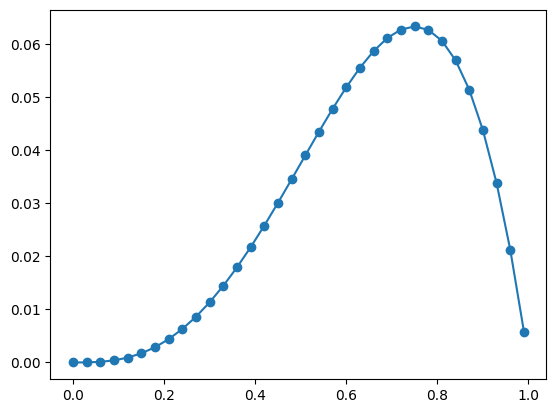

In [88]:
# (2)

grid_approx(3, 4, 30)

In [89]:
round(1/30, ndigits = 2)

0.03

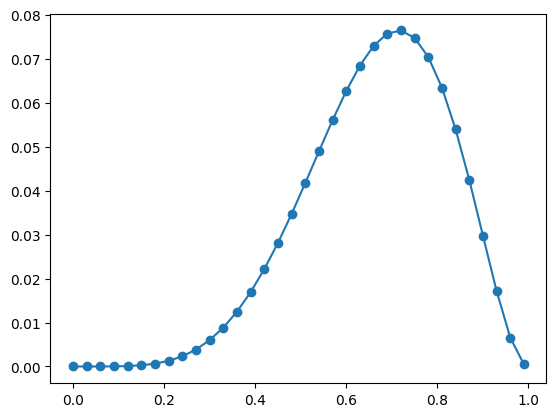

In [90]:
# (3)

grid_approx(5, 7, 30)

**2M2) Now assume a prior for *p* that is equal to zero when $p<0.5$ and is a positive constant when $p>=0.5$. Again compute and plot the grid approximate posterior distribution for each of the sets of observations in teh problem just above**

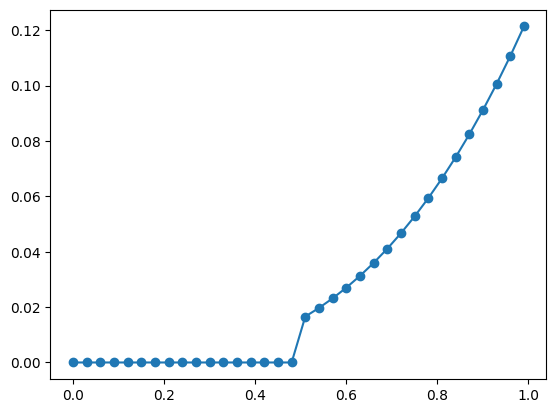

In [91]:
grid_approx(3, 3, prior='step')

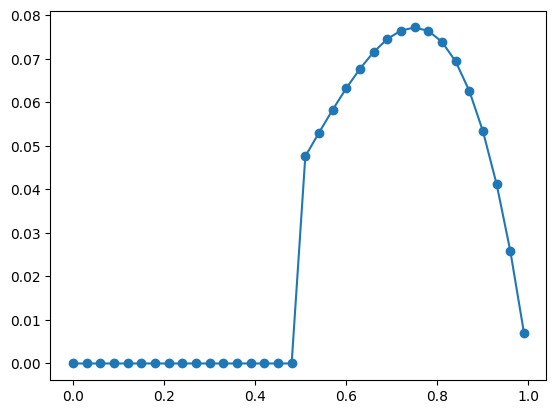

In [92]:
grid_approx(3, 4, prior='step')

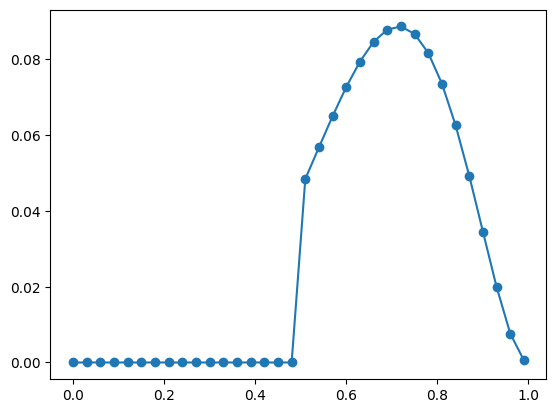

In [93]:
grid_approx(5, 7, prior='step')

**2M3) Suppose there are two globes, one for Earth and one for Mars. The Earth globe is 70% covered in water. The Mars globe is 100% land. Further suppose that one of these globes - you don't know which - was tossed in the air and produced a "land" observation. Assume that each globe was equally likely to be tossed. Show that the posterior probability that the globe was the Earth, conditional on seeing "land" (Pr(Earth|land)), is 0.23.**

Data story:
 * We have two globes each with the same probability of being tossed (prior = 1/2)
 * If earth is thrown, the probability of getting land is 0.3, if mars is thrown the probability of getting land is 1

In [94]:
pr_l_e = 0.3
pr_l_m = 1
pr_e = 0.5

print((pr_l_e*pr_e)/((pr_l_m*0.5+pr_l_e*0.5)))

## book answer

# probability of land, given Earth
p_le = 0.3
# probability of land, given Mars
p_lm = 1.0

# probability of Earth
p_e = 0.5

# probability of land
p_l = (p_e * p_le) + ((1 - p_e) * p_lm)

# probability of Earth, given land (using Bayes' Theorem)
p_el = (p_le * p_e) / p_l
print(p_el)

0.23076923076923075
0.23076923076923075


**2M4) Suppose you have a deck with only three cards. Each card has two sides, and each side is either black or white. One card has two black sides. The second card has one black and one white side. The third card has two white sides. Now suppose all three cards are placed in a back and shuffled. Someone reaches into the bag and pulls out a card and places it flat on a table. A black side is shown facing up. but you don't know the color of the side facing down. Show that the probability that the other side is also black is 2/3. Use the counting method (section 2 of the chapter) to approach this problem. This means counting up the ways that each card could produce the observed data (a black side facing up on the table).**

Using the counting method we can make this table:


|Conjecture| Ways to produce|
|----------|----------------|
|Card 1 Black face| 1X2=2 |
|Card 2 Black Face| 1X1=1 |
|Card 3 Black Face| 1X0=0 |


With this data, there are two cards that have black faces, one of which has 2 black faces, the other has 1. In all there are three ways to get a black face, two of which come from card 1. 

In [98]:
# Book answer

card_bb_l = 2
card_bw_l = 1
card_ww_l = 0

likelihood = [card_bb_l, card_bw_l, card_ww_l]
prior = [1, 1, 1]

posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior_bb = posterior[0] / sum(posterior)

posterior_bb


0.6666666666666666

**2M5) Now suppose there are four cards: B/B, B/W, W/W, and another B/B. Again suppose a card is drawn form the bag and a black side appears face up. Again calculate the probability that the other side is black.**



In [99]:
card_bb_l = 2
bard_bw_l = 1
bard_ww_w = 0

likelihood = [card_bb_l, card_bw_l, card_ww_l]
prior = [2, 1, 1]

posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior_bb = posterior[0] / sum(posterior)

posterior_bb

0.8

**2M6) Imagine that black ink is heavy, and so cards with balck sides are heavier than cards with white sides. As a result, it's less likely that a card with black sides is pulled from the bag. So again assume there are three cards: B/B, B/W, and W/W. After experimenting a number of times, you conclude that for every way to pull the B/B card from the bag, there are 2 ways to pull the B/W and 3 ways to pull the W/W card. Again suppose that a card is pulled and a balck side appears face up. Show taht the probability the other side is black is now 0.5. Use the counting method as before**

In [100]:
card_bb_l = 2
card_bw_l = 1
card_ww_l = 0

likelihood = [card_bb_l, card_bw_l, card_ww_l]
prior = [1, 2, 3]

posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior_bb = posterior[0] / sum(posterior)

posterior_bb

0.5

**2M7) Assume again the original card problem, with a single card showing a black side face up. Before looking at the other side, we draw another card form the bag and lay it face up on the table. The face that is shown on the new card is white. Show that the probability that the first card, the one showing a black side, has black on its other side is now 0.75. Use the counting method if you can

In [104]:
card_bb_l = 2
card_bw_l = 1
card_ww_l = 0

likelihood = [card_bb_l, card_bw_l, card_ww_l]
prior = [3, 2, 0]

posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior_bb = posterior[0] / sum(posterior)
posterior_bb

0.75

In [ ]:
# Book answer
# 2 choices for first card, with 3 options for second card: 2 W/W + 1 W/B
# card_bb_likelihood <- 2 * 3 
# card_wb_likelihood <- 1 * 2 
# card_ww_likelihood <- 0
# 
# likelihood <- c(card_bb_likelihood, card_wb_likelihood, card_ww_likelihood)
# prior <- c(1,1,1)
# posterior <- prior * likelihood
# posterior <- posterior / sum(posterior)
# 
# posterior[1]

**2H1) Suppose there are two species of panda bear. Both are equally common in the wild and live in the same places. They look exactly alike and eat the same food, and there is yet no genetic assay capable of telling them apart. They differ however in their family sizes. Species A gives birth to twins 10% of the time, otherwise birthing a single infant. Species B births twins 20% of the time, otherwise birthing singleton infants. Assume these numbers are known with certainty, from many years of field research. Now suppose you are managing a captive panda breeding program. You have a new female panda of unknown species, and she has just given birth to twins. What is the probability that her next birth will also be twins.**

First need to find the probability of twins then multiple that by the probability of twins again **WRONG**

In [112]:
species_a_l = 0.10
species_b_l = 0.20

likelihood = [species_a_l, species_b_l]
prior = [0.5, 0.5]

p_twins_1 = sum(list(map(lambda x,y: x*y, likelihood, prior)))
p_twins_2 = sum(list(map(lambda x,y: x*y, likelihood, prior)))

answer = p_twins_1*p_twins_2
answer # Wrong

0.022500000000000006

In [116]:
# Book answer

# After first birth, likelihood of species A and B is equal to the rate the
# species give birth to twins
species_a_l = 0.10
species_b_l = 0.20

# Next calculate the posterior probability that the panda belongs to each
# species, assume species are equally likely
likelihood = [species_a_l, species_b_l]
prior = [1,1]

posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior = [x / sum(posterior) for x in posterior]

# The probability the next birth is twins is the probability the panda belongs
# to each species times the likelihood each species gives birth to twins
answer = (posterior[0]*species_a_l) + (posterior[1]*species_b_l)
posterior, answer

([0.3333333333333333, 0.6666666666666666], 0.16666666666666666)

**2H2) Recall all the facts from the problem above. Now compute the probability that the panda we have is from species A, assuming we have observed only the first birth and that it was twins**

Need to calculate $Pr(Species A | twins)$

In [118]:
species_a_l = 0.1
pecies_b_l = 0.2

likelihood = [species_a_l, species_b_l]
prior = [1, 1]

posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior_a = posterior[0]/sum(posterior)

posterior_a

0.3333333333333333

In [119]:
# Book Answer

# probability of species A
p_a = 0.5

# probability of twins, given species A
p_ta = 0.1

# probability of twins, given species B
p_tb = 0.2

# probability of twins
p_t = (p_a * p_ta) + ((1 - p_a) * p_tb)

# probability of species A, given twins (using Bayes' Theorem)
# (note this is equivalent to `posterior[1]` above)
p_at = (p_ta * p_a) / p_t
p_at

0.3333333333333333

**2H3) Continuing on from the previous problem, suppose the same panda mother has a second birth and that it is not twins, but a singleton infant. Compute the posterior probability that this pandas is Species A**

Define variables:

Unobserved:
 * Pr(Species A) = $p$

Observed:
 * Birth sequence: T, S

Known:
 * Pr(T | Species A) = 0.1
 * Pr(T | Species B) = 0.2

After one T, probability of Species A = 0.33333, probability of Species B = 1-0.33333 (From previous question)

In [ ]:
p_a = 1/3
p_ta = 0.1
p_tb = 0.2

#Probability of singleton

p_s = 1 - (p_a * p_ta) + ((1-p_a) * p_tb)

#Probabliy of species A, given T then S

p_ats = (1-(p_ta * p_a))/p_s
p_ats # WRONG

0.8787878787878787

In [124]:
# Book answer
# likelihood for each species is Pr(twins) * Pr(singleton)
a_likelihood = 0.1 * (1 - 0.1)
b_likelihood = 0.2 * (1 - 0.2)

# compute posterior probabilities
likelihood = [a_likelihood, b_likelihood]
prior = [1, 1]
posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior = [ x / sum(posterior) for x in posterior]

posterior[0]

0.36

**2H4) A common boast of Bayesian statisticians is that Bayesian inference makes it easy to use all of the data, even if the data are of different types. Suppose now that a veterinarian comes along who has a new genetic test that she claims can identify the species of our mother panda. But the test, like all tests, is imperfect. This is the information you have about the test:**
 * **The probability it corrrectly identifies a species A pandas is 0.8**
 * **The probability it correctly identifies a species B panda is 0.65**
 
**The vet administers the test to your panda and tells you that the test is positive for species A. First ignore your previous information from teh births and compute teh posterior probability that your pandas is speices A. Then redo your calculation, now using teh birth data as well**

$$Pr(Species A | Positive test) = \frac{Pr(Positive test | Species A)*Pr(Species A)}{Pr(Positive test | Species A)*Pr(Species A) + Pr(Positive test | SPecies B) * Pr(Speices B)}$$
$$Pr(Species A | Positive test) = \frac{0.8*0.5}{((0.8*0.5)+(0.65*0.5))}$$
$$Pr(Species A | Positive test) = 0.55$$

In [129]:
p_a = (0.8*0.5)/((0.8*0.5)+(0.35*0.5))
p_a
p_b = 1-p_a

a_likelihood = 0.1 * (1-0.1)
b_likelihood = 0.2 * (1-0.2)

likelihood = [a_likelihood, b_likelihood]
prior = [p_a, p_b]
posterior = list(map(lambda x,y: x*y, likelihood, prior))
posterior = [x / sum(posterior) for x in posterior]

posterior[0]

0.5625000000000001

0.6956521739130436